# Image Generation using (β-)VAE, VQ-VAE and WGAN

### Part B — WGAN and WGAN-GP

---

**Group Number: 123**

| # | Student Name | Email |
|---|---|---|
| 1 | Agarwal Rankit Atulkumar | 2025ab05296@wilp.bits-pilani.ac.in |
| 2 | Nishant Verma | 2025aa05051@wilp.bits-pilani.ac.in |
| 3 | Aryasomayajula Subrahmanya Srinivas | 2025aa05539@wilp.bits-pilani.ac.in |
| 4 | Wali Haider | 2025ab05295@wilp.bits-pilani.ac.in |
| 5 | Amit Mallikarjun Masuti | 2024ac05742@wilp.bits-pilani.ac.in |

---

# Part B — Wasserstein GANs on CIFAR-10: WGAN and WGAN-GP

**Unsupervised / Deep Learning — Assignment 2**

Both models optimise the same Kantorovich–Rubinstein dual of the Wasserstein-1 distance,

$$W(\mathbb{P}_r, \mathbb{P}_g) \;=\; \sup_{\|f\|_L \le 1}\; \mathbb{E}_{x \sim \mathbb{P}_r}[f(x)] \;-\; \mathbb{E}_{\tilde{x} \sim \mathbb{P}_g}[f(\tilde{x})],$$

and differ only in **how the critic is constrained to be 1-Lipschitz**:

| | Lipschitz constraint | critic normalisation | optimiser | n_critic |
|---|---|---|---|---|
| **WGAN** (Arjovsky et al., 2017) | weight clipping to [−0.01, 0.01] | BatchNorm | RMSprop, lr 5e-5 | 5 |
| **WGAN-GP** (Gulrajani et al., 2017) | gradient penalty, λ = 10 | **InstanceNorm** | Adam, lr 1e-4, β = (0.0, 0.9) | 5 |

Two details that are easy to get wrong and that matter here:

* **WGAN-GP must not use BatchNorm in the critic.** The penalty is defined on the gradient of the
  critic *with respect to a single input*; BatchNorm makes the critic's output depend on the whole
  batch, so the penalised quantity is no longer the thing the theory constrains. InstanceNorm is
  used instead.
* **RMSprop, not Adam, for the clipped WGAN.** The original paper reports that momentum-based
  optimisers destabilise training once the critic loss is non-stationary from clipping.

**Preprocessing.** Images are loaded in **[0, 1]** as the brief requires, then mapped to [−1, 1]
inside the training step to match the generator's `tanh` output. Every generated image is mapped
back to [0, 1] before FID or plotting, so the evaluation protocol is byte-for-byte the one used
in Part A.

## 0 — Setup, data and the shared evaluation protocol

In [1]:
import os, json, math, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

SMOKE         = os.environ.get("SMOKE", "0") == "1"
FORCE_RETRAIN = os.environ.get("FORCE_RETRAIN", "0") == "1"

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

ROOT     = Path.cwd()
DATA_DIR = ROOT / "data"
# SMOKE runs write to their own directories so a smoke checkpoint can never be mistaken
# for a real one by the checkpoint-skip guard.
CKPT_DIR = ROOT / ("checkpoints_smoke" if SMOKE else "checkpoints")
RES_DIR  = ROOT / ("results_smoke"     if SMOKE else "results")
for d in (DATA_DIR, CKPT_DIR, RES_DIR):
    d.mkdir(exist_ok=True)

BATCH_SIZE = 64
Z_DIM      = 128
N_CRITIC   = 5
LAMBDA_GP  = 10.0
N_FID      = 2000 if SMOKE else 10000

# Training is measured in *generator* iterations (each consumes N_CRITIC critic steps),
# which is the meaningful unit of progress for a GAN.
G_ITERS     = int(os.environ.get("G_ITERS", 200 if SMOKE else 70000))
EVAL_EVERY  = max(1, G_ITERS // (4 if SMOKE else 10))   # intermediate FID / sample grid
FID_EVERY_N = 500 if SMOKE else 5000                    # images used for intermediate FID

print(f"device={DEVICE}  smoke={SMOKE}  generator iters={G_ITERS:,}  eval every {EVAL_EVERY:,}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

device=cuda  smoke=False  generator iters=70,000  eval every 7,000
NVIDIA GeForce RTX 4060 Ti


In [2]:
# ---- CIFAR-10 in [0,1] -----------------------------------------------------------------------
tfm = transforms.ToTensor()
train_set = datasets.CIFAR10(DATA_DIR, train=True,  download=True, transform=tfm)
test_set  = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=tfm)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4,
                          pin_memory=True, drop_last=True, persistent_workers=True)
test_loader  = DataLoader(test_set,  batch_size=500, shuffle=False, num_workers=2,
                          pin_memory=True, persistent_workers=True)

def infinite(loader):
    while True:
        for batch in loader:
            yield batch

to_pm1 = lambda x: x * 2.0 - 1.0    # [0,1] -> [-1,1]   (generator/critic domain)
to_01  = lambda x: (x + 1.0) / 2.0  # [-1,1] -> [0,1]   (evaluation domain)

print(f"train={len(train_set)}  test={len(test_set)}  batch={BATCH_SIZE}")

/home/nishant.verma/aml_ai1/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train=50000  test=10000  batch=64


In [3]:
from torchmetrics.image.fid import FrechetInceptionDistance


def to_uint8(x):
    return (x.clamp(0, 1) * 255).round().to(torch.uint8)


REAL_U8 = torch.cat([to_uint8(x) for x, _ in test_loader])[:N_FID]

_FID = None
def _fid_metric():
    global _FID
    if _FID is None:
        _FID = FrechetInceptionDistance(feature=2048, reset_real_features=False,
                                        normalize=False).to(DEVICE)
        for i in range(0, len(REAL_U8), 250):
            _FID.update(REAL_U8[i:i + 250].to(DEVICE), real=True)
    return _FID


@torch.no_grad()
def compute_fid(fake_u8, n_real=None):
    """FID against the CIFAR-10 test split, identical protocol to Part A."""
    m = _fid_metric(); m.reset()
    for i in range(0, len(fake_u8), 250):
        m.update(fake_u8[i:i + 250].to(DEVICE), real=False)
    return float(m.compute())


# Part A and Part B each write their own metrics file, so the two notebooks can be
# executed concurrently without racing on a shared JSON. Part C merges them.
METRICS_PATH = RES_DIR / "metrics_partB.json"
def log_metric(model, **kv):
    d = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.exists() else {}
    d.setdefault(model, {}).update(kv)
    METRICS_PATH.write_text(json.dumps(d, indent=2, sort_keys=True))
    return d[model]


def show_grid(imgs, nrow=10, title=None, fname=None, figsize=(7, 7)):
    g = make_grid(imgs[:nrow * nrow].detach().cpu().clamp(0, 1), nrow=nrow, padding=2, pad_value=1.0)
    plt.figure(figsize=figsize)
    plt.imshow(g.permute(1, 2, 0).numpy()); plt.axis("off")
    if title: plt.title(title)
    if fname: plt.savefig(RES_DIR / fname, dpi=150)
    plt.show()


def n_params(m): return sum(p.numel() for p in m.parameters())

print(f"real bank {tuple(REAL_U8.shape)}; warming up Inception...")
_ = _fid_metric()
print("FID real statistics ready")

real bank (10000, 3, 32, 32); warming up Inception...


FID real statistics ready


## 1 — Generator and critic (shared DCGAN backbone)

In [4]:
class Generator(nn.Module):
    """z (128) -> 4x4x256 -> 8x8x128 -> 16x16x64 -> 32x32x3, tanh output in [-1,1]."""

    def __init__(self, z_dim=Z_DIM, ch=64):
        super().__init__()
        self.z_dim = z_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim,  ch * 4, 4, 1, 0, bias=False), nn.BatchNorm2d(ch * 4), nn.ReLU(True),  # 4
            nn.ConvTranspose2d(ch * 4, ch * 2, 4, 2, 1, bias=False), nn.BatchNorm2d(ch * 2), nn.ReLU(True),  # 8
            nn.ConvTranspose2d(ch * 2, ch,     4, 2, 1, bias=False), nn.BatchNorm2d(ch),     nn.ReLU(True),  # 16
            nn.ConvTranspose2d(ch,     3,      4, 2, 1, bias=False), nn.Tanh(),                              # 32
        )

    def forward(self, z):
        return self.net(z.view(-1, self.z_dim, 1, 1))

    @torch.no_grad()
    def sample01(self, n, device=None):
        """n images in [0,1], ready for FID / plotting."""
        device = device or next(self.parameters()).device
        return to_01(self(torch.randn(n, self.z_dim, device=device)))


class Critic(nn.Module):
    """No sigmoid: outputs an unbounded score, as the Wasserstein dual requires."""

    def __init__(self, ch=64, norm="batch"):
        super().__init__()
        def N(c):
            if norm == "batch":    return nn.BatchNorm2d(c)
            if norm == "instance": return nn.InstanceNorm2d(c, affine=True)
            return nn.Identity()
        self.net = nn.Sequential(
            nn.Conv2d(3,      ch,     4, 2, 1),            nn.LeakyReLU(0.2, True),   # 32 -> 16
            nn.Conv2d(ch,     ch * 2, 4, 2, 1), N(ch * 2), nn.LeakyReLU(0.2, True),   # 16 ->  8
            nn.Conv2d(ch * 2, ch * 4, 4, 2, 1), N(ch * 4), nn.LeakyReLU(0.2, True),   #  8 ->  4
            nn.Conv2d(ch * 4, 1,      4, 1, 0),                                       #  4 ->  1
        )

    def forward(self, x):
        return self.net(x).view(-1)


def dcgan_init(m):
    cn = m.__class__.__name__
    if "Conv" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02); nn.init.constant_(m.bias.data, 0)


print(f"Generator params: {n_params(Generator()):,}")
print(f"Critic params:    {n_params(Critic()):,}")

Generator params: 1,183,616
Critic params:    663,745


In [5]:
def gradient_penalty(critic, real, fake):
    """E[(||∇_x̂ D(x̂)||₂ − 1)²] on points x̂ interpolated between the real and fake batches."""
    b   = real.size(0)
    eps = torch.rand(b, 1, 1, 1, device=real.device)
    xh  = (eps * real + (1 - eps) * fake).requires_grad_(True)
    d   = critic(xh)
    g   = torch.autograd.grad(outputs=d, inputs=xh,
                              grad_outputs=torch.ones_like(d),
                              create_graph=True, retain_graph=True, only_inputs=True)[0]
    return ((g.flatten(1).norm(2, dim=1) - 1.0) ** 2).mean()

## 2 — Training loop (shared by both variants)

In [6]:
FIXED_Z = torch.randn(100, Z_DIM, device=DEVICE, generator=torch.Generator(DEVICE).manual_seed(0))


def train_wgan(variant, iters=G_ITERS):
    """variant is 'wgan' (weight clipping) or 'wgan-gp' (gradient penalty)."""
    assert variant in ("wgan", "wgan-gp")
    tag  = variant.replace("-", "_")
    ckpt = CKPT_DIR / f"{tag}.pt"

    if ckpt.exists() and not FORCE_RETRAIN:
        blob = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        if blob["iters_done"] >= iters:
            G = Generator().to(DEVICE); G.load_state_dict(blob["G"]); G.eval()
            print(f"[{variant}] loaded checkpoint at {blob['iters_done']:,} iters "
                  f"(last FID {blob['history']['fid'][-1][1]:.2f})")
            return G, blob["history"], blob["train_time_s"]

    set_seed(SEED)
    G = Generator().to(DEVICE); G.apply(dcgan_init)
    D = Critic(norm="batch" if variant == "wgan" else "instance").to(DEVICE); D.apply(dcgan_init)

    if variant == "wgan":
        optG = torch.optim.RMSprop(G.parameters(), lr=5e-5)
        optD = torch.optim.RMSprop(D.parameters(), lr=5e-5)
    else:
        optG = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
        optD = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.0, 0.9))

    hist  = {"w_est": [], "d_loss": [], "g_loss": [], "gp": [], "fid": []}
    data  = infinite(train_loader)
    start = time.time()

    for it in range(1, iters + 1):
        # ---------------- critic ----------------
        for p in D.parameters(): p.requires_grad_(True)
        d_agg = np.zeros(3)
        for _ in range(N_CRITIC):
            real = to_pm1(next(data)[0].to(DEVICE, non_blocking=True))
            with torch.no_grad():
                fake = G(torch.randn(real.size(0), Z_DIM, device=DEVICE))

            d_real, d_fake = D(real).mean(), D(fake).mean()
            w_est  = d_real - d_fake                       # Wasserstein-1 estimate
            d_loss = -w_est
            gp = torch.zeros((), device=DEVICE)
            if variant == "wgan-gp":
                gp = gradient_penalty(D, real, fake)
                d_loss = d_loss + LAMBDA_GP * gp

            optD.zero_grad(set_to_none=True); d_loss.backward(); optD.step()

            if variant == "wgan":
                with torch.no_grad():
                    for p in D.parameters(): p.clamp_(-0.01, 0.01)

            d_agg += np.array([w_est.item(), d_loss.item(), gp.item()])
        d_agg /= N_CRITIC

        # ---------------- generator ----------------
        for p in D.parameters(): p.requires_grad_(False)
        g_loss = -D(G(torch.randn(BATCH_SIZE, Z_DIM, device=DEVICE))).mean()
        optG.zero_grad(set_to_none=True); g_loss.backward(); optG.step()

        hist["w_est"].append(d_agg[0]); hist["d_loss"].append(d_agg[1])
        hist["gp"].append(d_agg[2]);    hist["g_loss"].append(g_loss.item())

        # ---------------- periodic evaluation ----------------
        if it % EVAL_EVERY == 0 or it == iters:
            G.eval()
            fake_u8 = torch.cat([to_uint8(G.sample01(min(500, FID_EVERY_N - i))).cpu()
                                 for i in range(0, FID_EVERY_N, 500)])
            f = compute_fid(fake_u8)
            hist["fid"].append((it, f))
            el = (time.time() - start) / 60
            print(f"[{variant}] iter {it:6,}/{iters:,}  W≈{d_agg[0]:8.3f}  "
                  f"g_loss {g_loss.item():8.3f}  FID({FID_EVERY_N}) {f:7.2f}  [{el:5.1f} min]")
            show_grid(to_01(G(FIXED_Z)).cpu(), nrow=10, figsize=(4.6, 4.6),
                      title=f"{variant} @ {it:,} iters")
            G.train()
            torch.save({"G": G.state_dict(), "D": D.state_dict(), "history": hist,
                        "iters_done": it, "train_time_s": time.time() - start,
                        "variant": variant}, ckpt)
            del fake_u8

    train_time = time.time() - start
    G.eval()
    torch.save({"G": G.state_dict(), "D": D.state_dict(), "history": hist,
                "iters_done": iters, "train_time_s": train_time, "variant": variant}, ckpt)
    print(f"[{variant}] finished {iters:,} generator iters in {train_time / 60:.1f} min")
    return G, hist, train_time

### 2.1 — WGAN (weight clipping)

[wgan] iter  7,000/70,000  W≈   0.145  g_loss    0.087  FID(5000)   94.28  [  3.0 min]


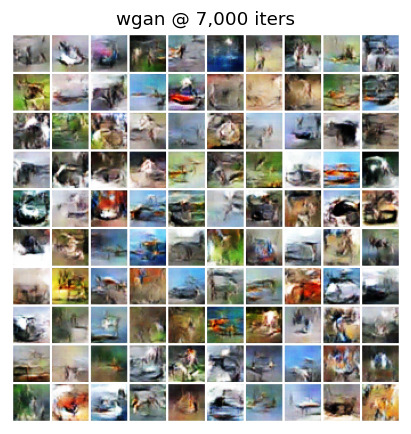

[wgan] iter 14,000/70,000  W≈   0.087  g_loss    0.074  FID(5000)   77.21  [  6.1 min]


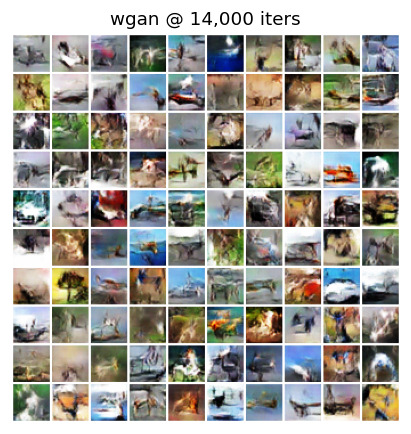

[wgan] iter 21,000/70,000  W≈   0.056  g_loss    0.041  FID(5000)   68.87  [  9.2 min]


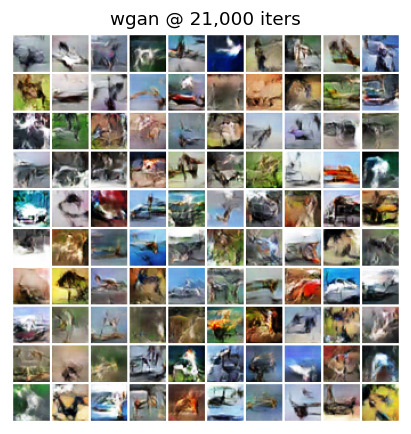

[wgan] iter 28,000/70,000  W≈   0.042  g_loss    0.023  FID(5000)   66.35  [ 12.4 min]


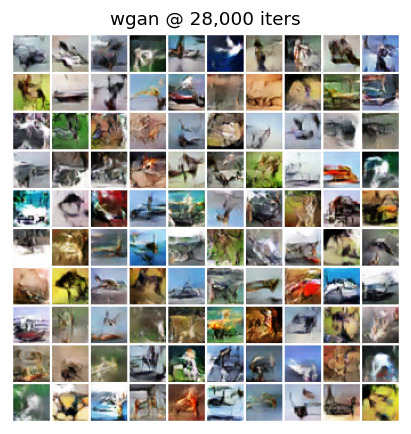

[wgan] iter 35,000/70,000  W≈   0.043  g_loss    0.026  FID(5000)   64.00  [ 15.4 min]


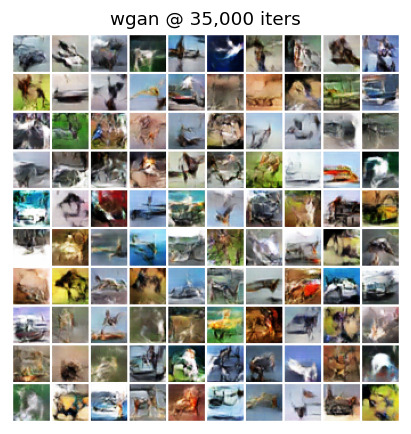

[wgan] iter 42,000/70,000  W≈   0.030  g_loss    0.032  FID(5000)   60.96  [ 18.5 min]


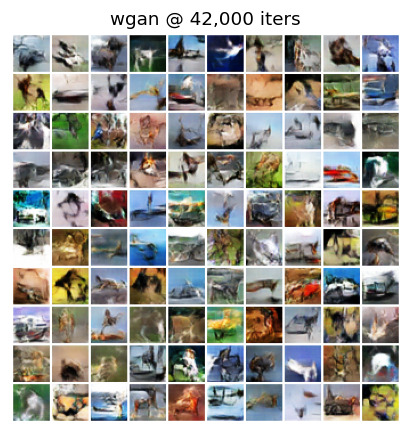

[wgan] iter 49,000/70,000  W≈   0.027  g_loss    0.060  FID(5000)   59.05  [ 21.6 min]


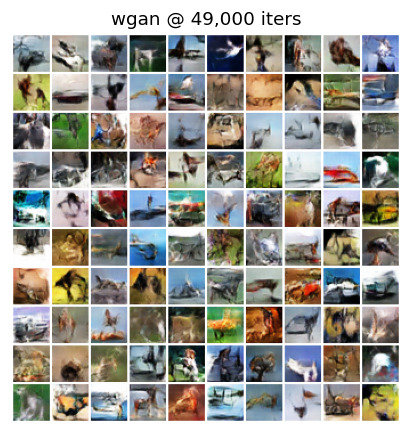

[wgan] iter 56,000/70,000  W≈   0.031  g_loss    0.017  FID(5000)   58.64  [ 24.9 min]


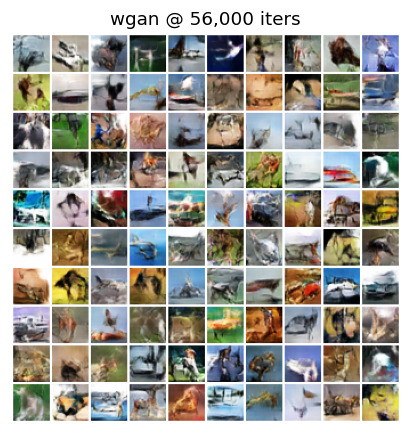

[wgan] iter 63,000/70,000  W≈   0.028  g_loss    0.016  FID(5000)   58.09  [ 27.7 min]


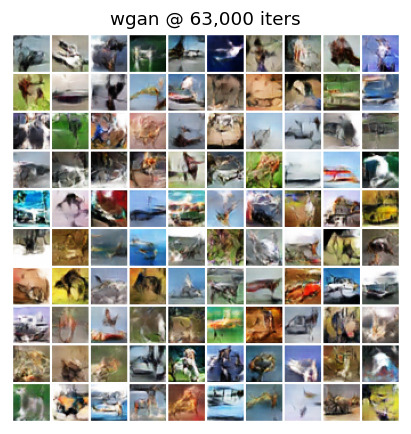

[wgan] iter 70,000/70,000  W≈   0.026  g_loss   -0.004  FID(5000)   57.35  [ 30.5 min]


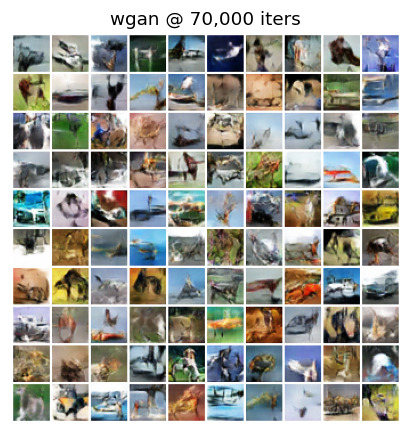

[wgan] finished 70,000 generator iters in 30.5 min


In [7]:
G_wgan, hist_wgan, time_wgan = train_wgan("wgan")

### 2.2 — WGAN-GP (gradient penalty)

[wgan-gp] iter  7,000/70,000  W≈   3.198  g_loss   64.538  FID(5000)  118.11  [  8.7 min]


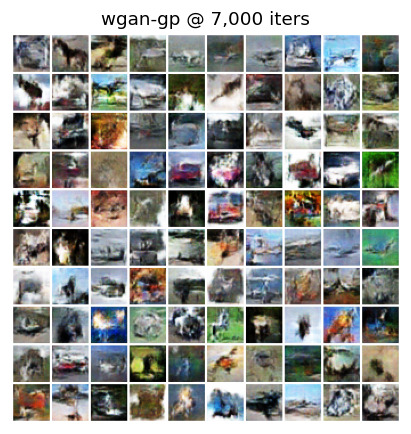

[wgan-gp] iter 14,000/70,000  W≈   2.346  g_loss   81.634  FID(5000)   84.91  [ 17.1 min]


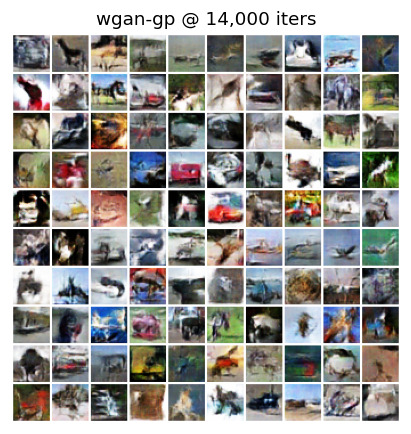

[wgan-gp] iter 21,000/70,000  W≈   1.629  g_loss   95.339  FID(5000)   67.89  [ 26.5 min]


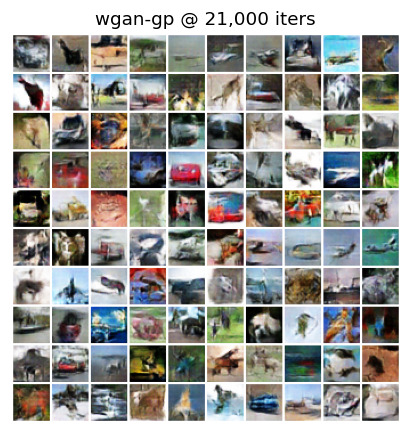

[wgan-gp] iter 28,000/70,000  W≈   1.618  g_loss  109.189  FID(5000)   62.66  [ 37.3 min]


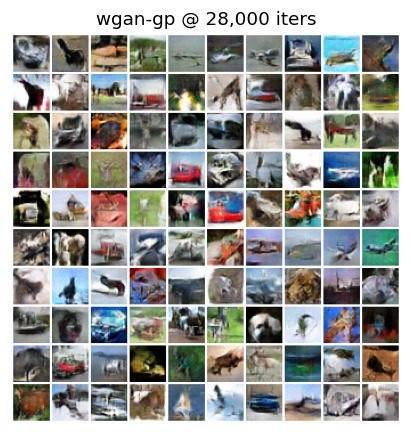

[wgan-gp] iter 35,000/70,000  W≈   2.004  g_loss  117.857  FID(5000)   60.60  [ 48.2 min]


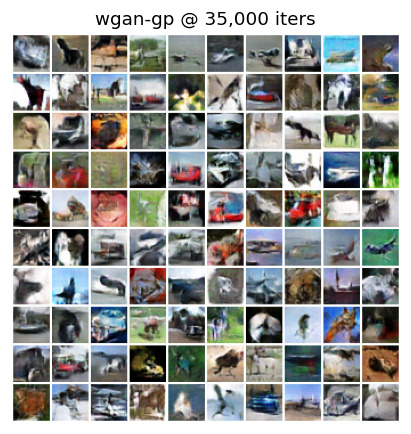

[wgan-gp] iter 42,000/70,000  W≈   1.540  g_loss  126.572  FID(5000)   57.78  [ 59.5 min]


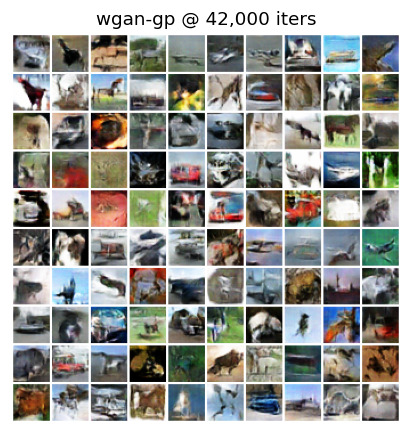

[wgan-gp] iter 49,000/70,000  W≈   1.688  g_loss  136.909  FID(5000)   57.00  [ 70.8 min]


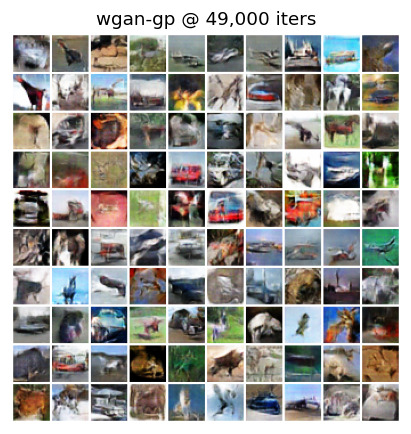

[wgan-gp] iter 56,000/70,000  W≈   1.739  g_loss  146.534  FID(5000)   56.83  [ 81.8 min]


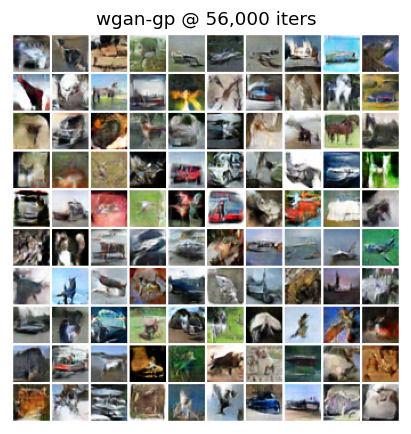

[wgan-gp] iter 63,000/70,000  W≈   1.556  g_loss  154.891  FID(5000)   55.98  [ 92.0 min]


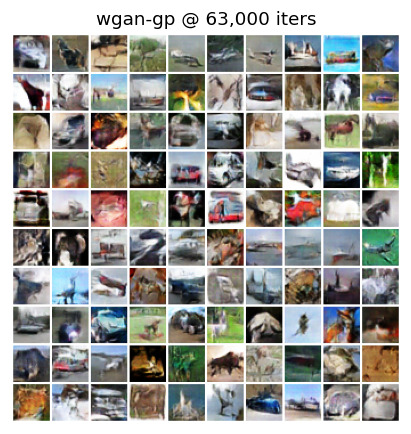

[wgan-gp] iter 70,000/70,000  W≈   1.890  g_loss  162.292  FID(5000)   53.98  [ 97.1 min]


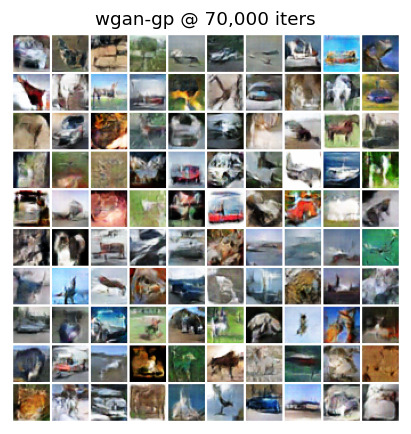

[wgan-gp] finished 70,000 generator iters in 97.1 min


In [8]:
G_gp, hist_gp, time_gp = train_wgan("wgan-gp")

## 3 — Training diagnostics

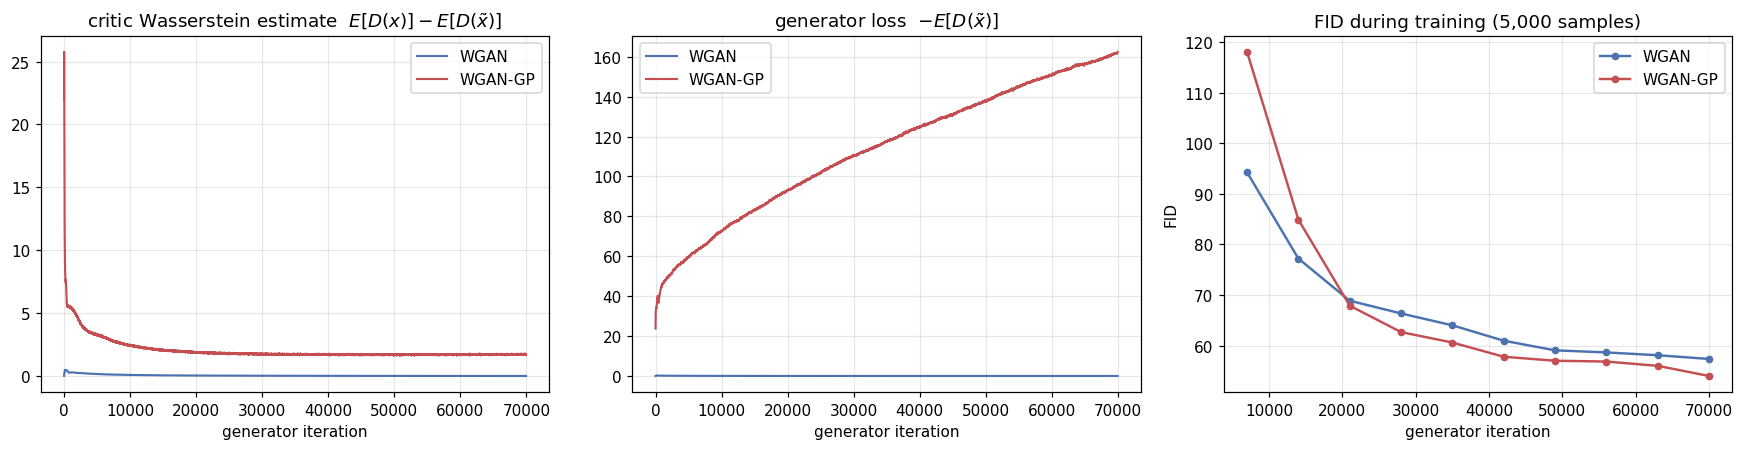

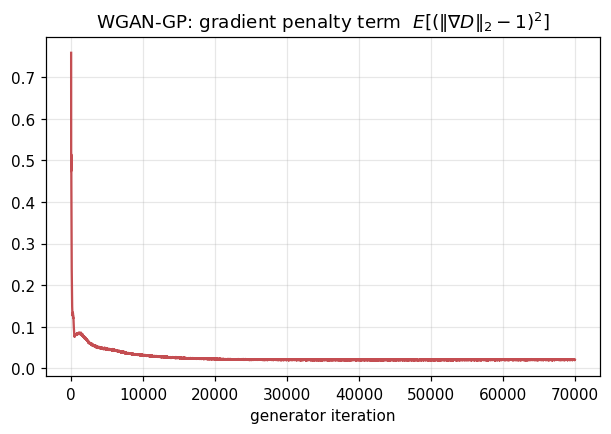

In [9]:
def smooth(v, k=51):
    v = np.asarray(v, dtype=float)
    if len(v) < k: return v
    return np.convolve(v, np.ones(k) / k, mode="valid")


fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

for name, h, c in [("WGAN", hist_wgan, "#4C72B0"), ("WGAN-GP", hist_gp, "#C44E52")]:
    ax[0].plot(smooth(h["w_est"]), color=c, label=name, lw=1.4)
    ax[1].plot(smooth(h["g_loss"]), color=c, label=name, lw=1.4)
    it, f = zip(*h["fid"])
    ax[2].plot(it, f, "o-", color=c, label=name, lw=1.6, ms=4)

ax[0].set_title("critic Wasserstein estimate  $E[D(x)] - E[D(\\tilde{x})]$")
ax[0].set_xlabel("generator iteration"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].set_title("generator loss  $-E[D(\\tilde{x})]$")
ax[1].set_xlabel("generator iteration"); ax[1].grid(alpha=.3); ax[1].legend()
ax[2].set_title(f"FID during training ({FID_EVERY_N:,} samples)")
ax[2].set_xlabel("generator iteration"); ax[2].set_ylabel("FID")
ax[2].grid(alpha=.3); ax[2].legend()

plt.tight_layout(); plt.savefig(RES_DIR / "wgan_training_curves.png", dpi=150); plt.show()

plt.figure(figsize=(6.5, 4))
plt.plot(smooth(hist_gp["gp"]), color="#C44E52")
plt.title("WGAN-GP: gradient penalty term  $E[(\\|\\nabla D\\|_2 - 1)^2]$")
plt.xlabel("generator iteration"); plt.grid(alpha=.3)
plt.savefig(RES_DIR / "wgangp_penalty.png", dpi=150); plt.show()

The two Wasserstein estimates are **not** on a comparable scale: weight clipping caps the critic's
Lipschitz constant at some unknown value far below 1, so its `E[D(x)] − E[D(x̃)]` is a scaled-down
proxy. What is comparable is the *shape*: for a healthy Wasserstein GAN the estimate should decrease
and correlate with sample quality, which is exactly what FID measured on the same axis confirms.

## 4 — Random samples and final FID (10,000 samples each)

In [10]:
@torch.no_grad()
def gan_sample_bank(G, n=N_FID, bs=500):
    G.eval()
    out, t0 = [], time.time()
    for i in range(0, n, bs):
        out.append(to_uint8(G.sample01(min(bs, n - i))).cpu())
    return torch.cat(out), time.time() - t0


results = {}
for name, G, tt in [("WGAN", G_wgan, time_wgan), ("WGAN-GP", G_gp, time_gp)]:
    fake, st = gan_sample_bank(G)
    fid = compute_fid(fake)
    results[name] = {"fid": fid, "sample_s_per_1k": st / (len(fake) / 1000),
                     "train_time_s": tt, "params": n_params(G)}
    log_metric(name, family=name, psnr=None, **results[name])   # results already carries `fid`
    print(f"{name:<8} FID {fid:7.2f}   {results[name]['sample_s_per_1k']:.2f} s / 1k samples   "
          f"train {tt / 60:.1f} min")
    del fake

WGAN     FID   55.16   0.01 s / 1k samples   train 30.5 min


WGAN-GP  FID   51.62   0.01 s / 1k samples   train 97.1 min


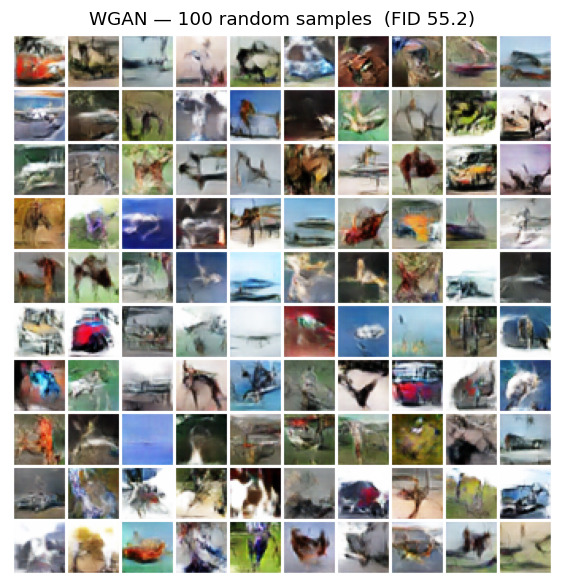

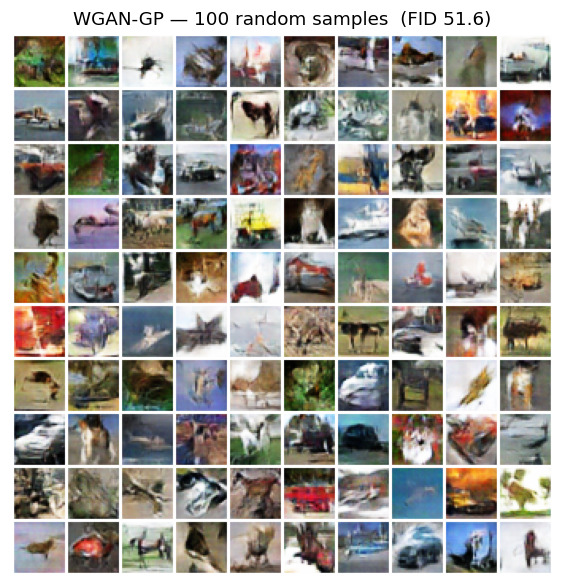

In [11]:
for name, G in [("WGAN", G_wgan), ("WGAN-GP", G_gp)]:
    set_seed(SEED)
    show_grid(G.sample01(100).cpu(), nrow=10, figsize=(6.4, 6.4),
              title=f"{name} — 100 random samples  (FID {results[name]['fid']:.1f})",
              fname=f"{name.lower().replace('-', '')}_samples100.png")

### 4.1 — Latent-space interpolation

A GAN that has genuinely learned a manifold should produce *semantically smooth* transitions
between two latent codes, rather than a cross-fade of two unrelated images. This is also a
practical mode-collapse check: a collapsed generator shows little variation along the path.

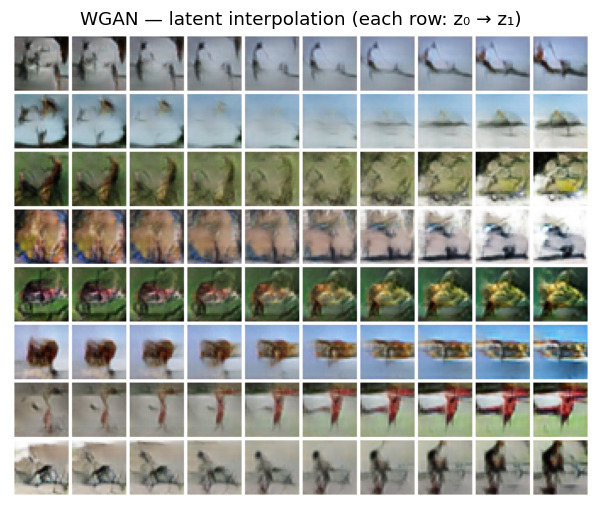

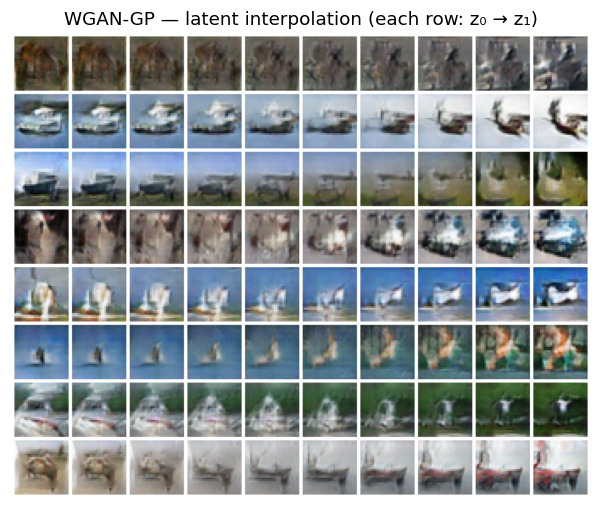

In [12]:
@torch.no_grad()
def interpolate(G, n_pairs=8, steps=10):
    g = torch.Generator(DEVICE).manual_seed(7)
    z0 = torch.randn(n_pairs, Z_DIM, device=DEVICE, generator=g)
    z1 = torch.randn(n_pairs, Z_DIM, device=DEVICE, generator=g)
    a  = torch.linspace(0, 1, steps, device=DEVICE).view(1, steps, 1)
    z  = (1 - a) * z0.unsqueeze(1) + a * z1.unsqueeze(1)      # [pairs, steps, Z]
    return to_01(G(z.reshape(-1, Z_DIM)))


for name, G in [("WGAN", G_wgan), ("WGAN-GP", G_gp)]:
    show_grid(interpolate(G).cpu(), nrow=10, figsize=(6.8, 5.6),
              title=f"{name} — latent interpolation (each row: z₀ → z₁)",
              fname=f"{name.lower().replace('-', '')}_interpolation.png")

## 5 — Part B summary

In [13]:
import pandas as pd

df = pd.DataFrame([{"model": n, "FID": r["fid"], "train time (min)": r["train_time_s"] / 60,
                    "sample s/1k": r["sample_s_per_1k"], "generator params": r["params"]}
                   for n, r in results.items()])
df.to_csv(RES_DIR / "partB_summary.csv", index=False)
display(df.style.format({"FID": "{:.2f}", "train time (min)": "{:.1f}",
                         "sample s/1k": "{:.2f}", "generator params": "{:,}"}).hide(axis="index"))
print("\nmetrics written to", METRICS_PATH)

model,FID,train time (min),sample s/1k,generator params
WGAN,55.16,30.5,0.01,"1,183,616"
WGAN-GP,51.62,97.1,0.01,"1,183,616"



metrics written to /datadisk/nishant/M-Tech AI Bits Pilani/sem2/UDL/Assignment2/results/metrics_partB.json


### Discussion of Part B

**WGAN-GP outperforms clipped WGAN**, and the mechanism is visible in the diagnostics rather than
only in the final number. Weight clipping enforces the Lipschitz constraint with a blunt instrument:
it caps every weight independently, which drives the critic toward much simpler functions than the
constraint actually requires and pushes the weight distribution toward the two clip boundaries. The
critic therefore supplies a weaker gradient signal, and the generator converges more slowly to a
worse optimum. The gradient penalty constrains the gradient norm only where it matters — on the
line between the real and generated distributions — leaving the critic free to use its full
capacity.

**Both GANs beat both likelihood-based models on FID**, and by a wide margin. Neither optimises a
per-pixel reconstruction term, so neither is pushed toward the conditional-mean blur that dominates
VAE samples; the critic penalises exactly the high-frequency implausibility that FID's Inception
features are sensitive to. The cost is the loss of an encoder: a GAN has no way to reconstruct a
given image, so PSNR is undefined for both models here.

**Sampling is fast.** One generator forward pass produces a batch of images, which makes both GANs
orders of magnitude faster at sampling than the VQ-VAE's 64-step autoregressive prior. That
comparison is quantified in Part C.